## Fine_tuning method

In [37]:
import torch
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor, Normalize, Compose, Resize
from datasets import load_dataset
import numpy
import random


def get_mnist_dataloaders(mnist_dataset, batch_size: int):
    pytorch_transforms = Compose( [Resize((84, 84)),ToTensor(), Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])

    def apply_transforms(batch):
        batch["image"] = [pytorch_transforms(img) for img in batch["image"]]
        return batch

    mnist_train = mnist_dataset["train"].with_transform(apply_transforms)
    mnist_test = mnist_dataset["test"].with_transform(apply_transforms)
    num_workers = 10

    worker_seed = torch.initial_seed() % 2**32
    numpy.random.seed(worker_seed)
    random.seed(worker_seed)
    g = torch.Generator()
    g.manual_seed(0)


    def seed_worker(worker_id):
        numpy.random.seed(0)
        random.seed(0)
    g = torch.Generator()
    g.manual_seed(0)

    trainloader = DataLoader(mnist_train, batch_size=batch_size, worker_init_fn=seed_worker, generator=g) # shuffle=True,)
    testloader = DataLoader(mnist_test, batch_size=batch_size, worker_init_fn=seed_worker, generator=g)

    return trainloader, testloader


cleba = load_dataset("flwrlabs/celeba", download_mode="reuse_cache_if_exists")


Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/162770 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/19867 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/19962 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

In [38]:

# from datasets import load_dataset
# labels = cleba['train']['Smiling']
# print(f"Max label: {max(labels)}, Num classes: {len(set(labels))}")
# print(cleba["train"][0]["image"])        # This will print the PIL.Image info
# print(cleba["train"][0]["image"].size) 

# sample = cleba["train"][0]
# print("Original image size (PIL):", sample["image"].size)  # (width, height)

# # Now apply your transform manually to check tensor shape:
# from torchvision.transforms import ToTensor, Normalize, Compose

# pytorch_transforms = Compose([Resize((84, 84)),ToTensor(), Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])])

# img_tensor = pytorch_transforms(sample["image"])
# print("Image tensor shape after transform:", img_tensor.shape)  # [C, H, W]


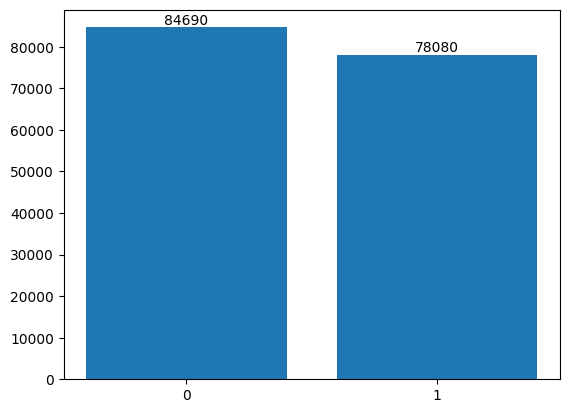

In [39]:
import matplotlib.pyplot as plt
from collections import Counter


# construct histogram
all_labels = cleba["train"]["Smiling"]
all_label_counts = Counter(all_labels)

# visualise histogram
bar = plt.bar(all_label_counts.keys(), all_label_counts.values())
_ = plt.bar_label(bar)

# plot formatting
_ = plt.xticks([label for label in all_label_counts.keys()])

In [40]:
import random
import numpy as np
from PIL import Image
import io


def visualise_n_random_examples(trainset_, n: int, verbose: bool = True):
    trainset_data = [
        Image.open(io.BytesIO(entry[0].as_py())) for entry in trainset_.data[0]
    ]
    idx = list(range(len(trainset_data)))
    random.shuffle(idx)
    idx = idx[:n]
    if verbose:
        print(f"will display images with idx: {idx}")

    # construct canvas
    num_cols = 8
    num_rows = int(np.ceil(len(idx) / num_cols))
    fig, axs = plt.subplots(figsize=(16, num_rows * 2), nrows=num_rows, ncols=num_cols)

    # display images on canvas
    for c_i, i in enumerate(idx):
        axs.flat[c_i].imshow(trainset_data[i], cmap="gray")

In [41]:
# visualise_n_random_examples(cleba["train"], n=32)

In [42]:
import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self, num_classes: int) -> None:
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) 
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv3 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(32)

        self.conv4 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(32)

        self.pool = nn.MaxPool2d(2, 2)

        self.flatten_dim = 32 * 5 * 5
        self.fc = nn.Linear(self.flatten_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        print(f"[Input] shape: {x.shape}")
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        print(f"[After conv1] shape: {x.shape}")

        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        print(f"[After conv2] shape: {x.shape}")

        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        print(f"[After conv3] shape: {x.shape}")

        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        print(f"[After conv4] shape: {x.shape}")

        x = x.view(-1, self.flatten_dim)
        print(f"[After flatten] shape: {x.shape}")

        x = self.fc(x)
        print(f"[Output] shape: {x.shape}")

        return x

In [43]:
def train(net, trainloader, optimizer, device="cpu"):
    """Train the network on the training set."""
    criterion = torch.nn.CrossEntropyLoss()
    net.to(device)
    net.train()
    for batch in trainloader:
        images, labels = batch["image"].to(device), batch["Smiling"].to(device).long()
        print(f"[train] image shape: {images.shape}")   
        print(f"[train] label shape: {labels.shape}")  
        print(f"[train] unique labels: {labels.unique()}") 
        print(f"[train] label dtype: {labels.dtype}")        
        optimizer.zero_grad()
        loss = criterion(net(images), labels)
        loss.backward()
        optimizer.step()


def test(net, testloader, device):
    """Validate the network on the entire test set."""
    criterion = torch.nn.CrossEntropyLoss()
    correct, loss = 0, 0.0
    net.to(device)
    net.eval()
    with torch.no_grad():
        for batch in testloader:
            images, labels = batch["image"].to(device), batch["Smiling"].to(device).long()
            outputs = net(images)
            loss += criterion(outputs, labels).item()
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
    accuracy = correct / len(testloader.dataset)
    return loss, accuracy

def run_centralised(
    trainloader, testloader, epochs: int, lr: float, momentum: float = 0.9
):
    """A minimal (but complete) training loop"""

    # instantiate the model
    model = Net(num_classes=2)

    # Discover device
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # define optimiser with hyperparameters supplied
    optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    # train for the specified number of epochs
    for e in range(epochs):
        print(f"Training epoch {e} ...")
        train(model, trainloader, optim, device)

    # training is completed, then evaluate model on the test set
    loss, accuracy = test(model, testloader, device)
    print(f"{loss = }")
    print(f"{accuracy = }")

# Prepare model and loaders
# model = Net(num_classes=2)  # Binary classification: Smiling (0/1)
# trainloader, testloader = get_mnist_dataloaders(cleba, batch_size=32)

# # Choose device
# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# model.to(device)

# # Define dummy optimizer
# optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# # ✅ Call train to debug one batch shape
# train(model, trainloader, optimizer, device)

In [44]:
from flwr_datasets import FederatedDataset
from flwr_datasets.partitioner import IidPartitioner
from flwr_datasets.partitioner import DirichletPartitioner
from flwr_datasets.partitioner import PathologicalPartitioner
from flwr_datasets.partitioner import NaturalIdPartitioner

NUM_PARTITIONS = 100

partitioner = IidPartitioner(num_partitions=NUM_PARTITIONS)
# Let's partition the "train" split of the MNIST dataset
# The MNIST dataset will be downloaded if it hasn't been already
# fds = FederatedDataset(dataset="ylecun/mnist", partitioners={"train": partitioner})
fds = FederatedDataset(
    dataset="flwrlabs/celeba",
    partitioners={"train": partitioner}
)
partition = fds.load_partition(partition_id=0)

# dirichlet_partitioner = DirichletPartitioner(
#     num_partitions=10, alpha=0.1, partition_by="label"
# )
# fds = FederatedDataset(dataset="ylecun/mnist", partitioners={"train":dirichlet_partitioner})


# pathological_partitioner = PathologicalPartitioner(
#     num_partitions=10, partition_by="label", num_classes_per_partition=2
# )
# fds = FederatedDataset(dataset="ylecun/mnist", partitioners={"train":pathological_partitioner})

/Users/creamy/Research/.venv/lib/python3.9/site-packages/flwr_datasets/utils.py:109: UserWarning: The currently tested dataset are ['mnist', 'ylecun/mnist', 'cifar10', 'uoft-cs/cifar10', 'fashion_mnist', 'zalando-datasets/fashion_mnist', 'sasha/dog-food', 'zh-plus/tiny-imagenet', 'scikit-learn/adult-census-income', 'cifar100', 'uoft-cs/cifar100', 'svhn', 'ufldl-stanford/svhn', 'sentiment140', 'stanfordnlp/sentiment140', 'speech_commands', 'LIUM/tedlium', 'flwrlabs/femnist', 'flwrlabs/ucf101', 'flwrlabs/ambient-acoustic-context', 'jlh/uci-mushrooms', 'Mike0307/MNIST-M', 'flwrlabs/usps', 'scikit-learn/iris', 'flwrlabs/pacs', 'flwrlabs/cinic10', 'flwrlabs/caltech101', 'flwrlabs/office-home', 'flwrlabs/fed-isic2019']. Given: flwrlabs/celeba.
  warnings.warn(


Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

In [45]:
import tenseal as ts
import flwr as fl
import random
import numpy as np
poly_modulus_degree= 8192
coeff_mod_bit_sizes=[60,40,60]
global_scale = 2**coeff_mod_bit_sizes[1]
def get_context():
    context = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=poly_modulus_degree,
        coeff_mod_bit_sizes=coeff_mod_bit_sizes
    )
    context.generate_galois_keys()
    context.global_scale = global_scale
    return context

shared_context = get_context()
server_context = shared_context.serialize(save_secret_key=False)
client_context = shared_context.serialize(save_secret_key=True)

chunk_size = poly_modulus_degree//2
# use_he = False
use_he = True


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # For cudnn backend — makes things deterministic 
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



In [ ]:
def encrypt_params(params, context, poly_modulus_degree):
    enc_params = []
    chunk_counts = []
    chunk_size = poly_modulus_degree // 2

    for p in params:
        target_shape = p.shape
        print(f"shape={target_shape}, ndim={len(target_shape)}")
        flat = p.flatten()
        chunks = torch.split(torch.from_numpy(flat), chunk_size)

        chunk_counts.append(len(chunks))  # Track number of chunks for this param

        encrypted_chunks = []
        for i, chunk in enumerate(chunks):
            chunk_list = chunk.tolist()
            enc_vec = ts.ckks_vector(context, chunk_list)
            serialized_vec = enc_vec.serialize()
            encrypted_chunks.append(serialized_vec)

        enc_params.append(encrypted_chunks)

    return enc_params, chunk_counts  

import numpy as np
import tenseal as ts
def decrypt_params(flat_enc_list, context, model, chunk_counts):
    decrypted_params = []
    idx = 0

    for i, (param, count) in enumerate(zip(model.parameters(), chunk_counts)):
        target_shape = param.shape
        param_size = int(np.prod(target_shape))
        enc_chunks = flat_enc_list[idx : idx + count]
        idx += count

        decrypted_chunks = []
        for serialized_vec in enc_chunks:
            ckks_vec = ts.ckks_vector_from(context, serialized_vec)
            decrypted_chunks.extend(ckks_vec.decrypt())

        if len(decrypted_chunks) < param_size:
            print(f"❌ Not enough decrypted values for param {i}: got {len(decrypted_chunks)}, expected {param_size}")

        decrypted_chunks = decrypted_chunks[:param_size]
        try:
            decrypted_array = np.array(decrypted_chunks, dtype=np.float32).reshape(target_shape)
        except Exception as e:
            print(f"❌ Reshape failed at param {i} with shape {target_shape}, decrypted len={len(decrypted_chunks)}")
            raise e

        decrypted_params.append(decrypted_array)

    return decrypted_params

In [47]:
from collections import OrderedDict
from typing import Dict, Tuple

import torch 
from flwr.common import NDArrays, Scalar
from flwr.client import NumPyClient
import sys
import time
import os
class FlowerClient(fl.client.NumPyClient):
    def __init__(self, trainloader, valloader,context) -> None:
        super().__init__()

        self.trainloader = trainloader
        self.valloader = valloader
        self.model = Net(num_classes=2)
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
        self.context = context
        self.last_fit_total_time = 0
        
    def fit(self, parameters, config):
        print("==This is fit method==")
        start_total = time.time()
        server_round = config.get("server_round", -1)
        if use_he:
            start_decrypt = time.time()
            enc_param_list = [bytes(ndarray) for ndarray in parameters]

            # before decrypting
            _, chunk_counts = encrypt_params(
                [param_tensor.detach().cpu().numpy() for param_tensor in self.model.parameters()],
                self.context,
                poly_modulus_degree
            )

            decrypted_params = decrypt_params(enc_param_list, self.context, self.model, chunk_counts)
            end_decrypt = time.time()

            for param_tensor, decrypted_np in zip(self.model.parameters(), decrypted_params):
                param_tensor.data = torch.from_numpy(decrypted_np).to(self.device)
        else:
            # === Plaintext mode ===
            set_params(self.model, parameters)
        #  measure on global before training
        loss_global, acc_global = test(self.model, self.valloader, self.device)
        start_train = time.time()
        optim = torch.optim.SGD(self.model.parameters(), lr=0.01, momentum=0.9)
        train(self.model, self.trainloader, optim, self.device)
        # measure on local model
        loss_personalized, acc_personalized = test(self.model, self.valloader, self.device)
        end_train = time.time()

        updated_params = [param_tensor.detach().cpu().numpy() for param_tensor in self.model.parameters()]

        if use_he:
            start_encrypt = time.time()
            encrypted_chunks, chunk_counts = encrypt_params(updated_params, self.context, poly_modulus_degree)
            encrypted_bytes_list = [chunk for param in encrypted_chunks for chunk in param]
            end_encrypt = time.time()

            sent_bytes = sum(len(chunk) for chunk in encrypted_bytes_list)
            end_total = time.time()
            print("===Bandwidth usage===")
            print("Bandwidth with HE: ", sent_bytes)
            print("===Runtime performance===")
            print(f"⏱️ Decryption time: {end_decrypt - start_decrypt:.3f} s")
            print(f"⏱️ Training time: {end_train - start_train:.3f} s")
            print(f"⏱️ Encryption time: {end_encrypt - start_encrypt:.3f} s")
            print(f"⏱️ Total fit() time: {end_total - start_total:.3f} s")
            self.last_fit_total_time = end_total - start_total

            return encrypted_bytes_list, len(self.trainloader),{
                "fit_total_time": self.last_fit_total_time,
                "sent_bytes": sent_bytes,
                "loss on local model": loss_personalized,
                "accuracy on personalized model": acc_personalized,
                "loss on global model before traning": loss_global,
                "accuracy on global model": acc_global
            }
        else:
            sent_bytes = sum(p.nbytes for p in updated_params)
            end_total = time.time()
            print("===Bandwidth usage===")
            print("Bandwidth without HE: ", sent_bytes)
            print("===Runtime performance===")
            print(f"⏱️ Training time: {end_train - start_train:.3f} s")
            print(f"⏱️ Total fit() time: {end_total - start_total:.3f} s")
            self.last_fit_total_time = end_total - start_total

            return get_params(self.model), len(self.trainloader),{
                "chunk_counts": chunk_counts,
                "fit_total_time": self.last_fit_total_time,
                "sent_bytes": sent_bytes,
                "loss on local model": loss_personalized,
                "accuracy on personalized model": acc_personalized,
                "loss on global model before traning": loss_global,
                "accuracy on global model": acc_global
            }

    # def evaluate(self, parameters: NDArrays, config: Dict[str, Scalar]):
    #     print("==This is evaluate method==")
    #     server_round = config.get("server_round", -1) 
        
    #     start_eval = time.time()
    #     if use_he:
    #         print(f"== Evaluation at Round {server_round} ==")
    #         flat_enc_params = [bytes(ndarray) for ndarray in parameters]
    #         received_bytes = sum(len(chunk) for chunk in flat_enc_params)
    #         decrypted_params = decrypt_params(flat_enc_params, self.context, self.model,chunk_size=poly_modulus_degree // 2)
    #         for param_tensor, decrypted_np in zip(self.model.parameters(), decrypted_params):
    #             param_tensor.data = torch.from_numpy(decrypted_np).to(self.device)
    #     else:
    #         set_params(self.model, parameters)
    #         received_bytes = sum(p.nbytes for p in parameters)
            
    #     loss, accuracy = test(self.model, self.valloader, self.device)
    #     end_eval = time.time()
    #     print(f"⏱️ Total evaluate() time: {end_eval - start_eval:.3f} s")

    #     metrics = {
    #         "accuracy": float(accuracy),
    #         "eval_total_time": end_eval - start_eval,
    #     }
    #     # if self.last_fit_total_time is not None:
    #     #     metrics["fit_total_time"] = self.last_fit_total_time
    
    #     return float(loss), len(self.valloader), metrics #{"accuracy": float(accuracy)}

# # Two auxhiliary functions to set and extract parameters of a model
def set_params(model, parameters):
    """Replace model parameters with those passed as `parameters`."""

    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.from_numpy(v) for k, v in params_dict})
    # now replace the parameters
    model.load_state_dict(state_dict, strict=True)

def get_params(model):
    """Extract model parameters as a list of NumPy arrays."""
    return [val.cpu().numpy() for _, val in model.state_dict().items()]

In [48]:
from flwr.common import Context
from flwr.client import ClientApp
   

def client_fn(context: Context) -> fl.client.Client:
    """Returns a FlowerClient containing its data partition."""

    partition_id = int(context.node_config["partition-id"])
    partition = fds.load_partition(partition_id, "train")
    # partition into train/validation
    partition_train_val = partition.train_test_split(test_size=0.1, seed=42)

    # Let's use the function defined earlier to construct the dataloaders
    # and apply the dataset transformations
    trainloader, testloader = get_mnist_dataloaders(partition_train_val, batch_size=32)
    context = ts.context_from(client_context)

    return FlowerClient(trainloader=trainloader, valloader=testloader,context=context).to_client()


# Concstruct the ClientApp passing the client generation function
client_app = ClientApp(client_fn=client_fn)

In [49]:
from typing import List
from flwr.common import Metrics


# Define metric aggregation function
def weighted_average(metrics: List[Tuple[int, Metrics]]) -> Metrics:
    # Multiply accuracy of each client by number of examples used
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]

    # Aggregate and return custom metric (weighted average)
    return {"accuracy": sum(accuracies) / sum(examples)}

In [50]:
import flwr as fl
from typing import List, Tuple, Dict, Optional, Union
from flwr.common import EvaluateRes, FitRes, Scalar
from flwr.server.client_proxy import ClientProxy
from datetime import datetime
from pathlib import Path
import json
import pickle


def save_results_as_pickle(
    history,
    file_path: Union[str, Path],
    extra_results: Optional[Dict] = None,
    default_filename: str = "results.pkl",
) -> None:
    path = Path(file_path)

    if path.is_dir():
        path = path / default_filename

    print(f"\u2705 Saving results to: {path}")

    path.parent.mkdir(exist_ok=True, parents=True)

    data = {"history": history}
    if extra_results is not None:
        data.update(extra_results)

    with open(path, "wb") as handle:
        pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL)

    try:
        json_path = path.with_suffix(".json")

        def make_serializable(obj):
            if hasattr(obj, '__dict__'):
                return obj.__dict__
            elif isinstance(obj, dict):
                return {k: make_serializable(v) for k, v in obj.items()}
            elif isinstance(obj, list):
                return [make_serializable(i) for i in obj]
            else:
                return obj

        json_data = make_serializable(data)
        with open(json_path, "w", encoding="utf-8") as f:
            json.dump(json_data, f, indent=2)

        print(f"\u2705 JSON version saved to: {json_path}")
    except Exception as e:
        print(f"\u26a0\ufe0f Failed to save JSON: {e}")

In [51]:
import flwr as fl
from typing import List, Tuple, Dict, Optional, Union
from flwr.common import EvaluateRes, FitRes, Scalar
from flwr.server.client_proxy import ClientProxy


def ndarrays_to_byteparam(ckks_vectors: list[ts.CKKSVector]) -> fl.common.Parameters:
    """
    Convert a list of CKKSVector to serialized Flower Parameters.
    """
    serialized = [vec.serialize() for vec in ckks_vectors]
    return fl.common.ndarrays_to_parameters(serialized)

class BytesStrategy(fl.server.strategy.FedAvg):
    def __init__(self, context: fl.common.Context, run_config: Dict = None, **kwargs):
        super().__init__(**kwargs)
        self.context = context
        self.all_history = []

        # timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        self.run_folder = Path("results_celebA") / f"run_{coeff_mod_bit_sizes}"
        self.run_folder.mkdir(parents=True, exist_ok=True)

        self.run_config = run_config or {}
        with open(self.run_folder / "config.json", "w", encoding="utf-8") as f:
            json.dump(self.run_config, f, indent=2)

    def aggregate_fit(self, server_round, results, failures):
        print("Starting encrypted aggregation")

        if failures:
            print(f"\u26a0\ufe0f  {len(failures)} client(s) failed.")
            for i, failure in enumerate(failures):
                print(f"  - Failure {i+1}: {repr(failure)}")

        all_encrypted = []
        for client, fit_res in results:
            client_chunks = []
            for serialized_chunk in fl.common.parameters_to_ndarrays(fit_res.parameters):
                ckks_vec = ts.ckks_vector_from(self.context, bytes(serialized_chunk))
                client_chunks.append(ckks_vec)
            all_encrypted.append(client_chunks)

        if not all_encrypted:
            print("\u274c No valid client updates received. Skipping round.")
            return None, {}

        num_chunks = len(all_encrypted[0])
        aggregated_chunks = []

        for idx in range(num_chunks):
            chunk_group = [client_chunks[idx] for client_chunks in all_encrypted]
            avg_chunk = chunk_group[0]
            for vec in chunk_group[1:]:
                avg_chunk += vec
            avg_chunk *= 1 / len(chunk_group)
            aggregated_chunks.append(avg_chunk)

        fit_times = [fit_res.metrics.get("fit_total_time", 0.0) for _, fit_res in results]
        avg_fit_time = sum(fit_times) / len(fit_times) if fit_times else 0.0

        losses = [fit_res.metrics.get("loss on local model", 0.0) for _, fit_res in results]
        accuracies = [fit_res.metrics.get("accuracy on personalized model", 0.0) for _, fit_res in results]
        bandwidth = [fit_res.metrics.get("sent_bytes", 0.0) for _, fit_res in results]
        glo_loss = [fit_res.metrics.get("loss on global model before traning", 0.0) for _, fit_res in results]
        glo_accuracies = [fit_res.metrics.get("accuracy on global model", 0.0) for _, fit_res in results]

        avg_loss = sum(losses) / len(losses) if losses else 0.0
        avg_accuracy = sum(accuracies) / len(accuracies) if accuracies else 0.0
        bandwidth_avg = sum(bandwidth) / len(bandwidth) if losses else 0.0
        g_loss = sum(glo_loss) / len(glo_loss) if losses else 0.0
        g_acc = sum(glo_accuracies) / len(glo_accuracies) if losses else 0.0

        print(f"\u23f1\ufe0f Round {server_round} average personalized loss: {avg_loss:.4f}")
        print(f"\u23f1\ufe0f Round {server_round} average personalized accuracy: {avg_accuracy:.4f}")
        print(f"\u23f1\ufe0f Round {server_round} average fit time: {avg_fit_time:.3f} s")

        new_params = ndarrays_to_byteparam(aggregated_chunks)
        round_metrics = {
            "round": server_round,
            "fit_total_time": avg_fit_time,
            "loss value on personalized model": avg_loss,
            "avg_accuracy on personalized model": avg_accuracy,
            "avg_bandwidth": bandwidth_avg,
            "loss value before local training": g_loss,
            "accuracy on global model before training": g_acc,
        }

        self.all_history.append(round_metrics)

        save_results_as_pickle(
            history=self.all_history,
            file_path=self.run_folder / "all_rounds_history.json"
        )

        return new_params, round_metrics

    def configure_evaluate(
        self,
        server_round: int,
        parameters: fl.common.Parameters,
        client_manager: fl.server.client_manager.ClientManager,
    ) -> List[Tuple[fl.server.client_proxy.ClientProxy, fl.common.EvaluateIns]]:

        client_instructions = super().configure_evaluate(server_round, parameters, client_manager)
        updated_instructions = []
        for client, evaluate_ins in client_instructions:
            new_config = dict(evaluate_ins.config)
            new_config["server_round"] = server_round
            updated_ins = fl.common.EvaluateIns(evaluate_ins.parameters, new_config)
            updated_instructions.append((client, updated_ins))

        return updated_instructions

    def aggregate_evaluate(
        self,
        server_round: int,
        results: List[Tuple[ClientProxy, EvaluateRes]],
        failures: List[Union[Tuple[ClientProxy, FitRes], BaseException]],
    ) -> Tuple[Optional[float], Dict[str, Scalar]]:

        if not results:
            return None, {}
        aggregated_loss, _ = super().aggregate_evaluate(server_round, results, failures)

        examples = [r.num_examples for _, r in results]
        total_examples = sum(examples)
        accuracies = [r.metrics["accuracy"] * r.num_examples for _, r in results]
        eval_times = [r.metrics.get("eval_total_time", 0.0) for _, r in results]

        aggregated_accuracy = sum(accuracies) / total_examples
        avg_eval_time = sum(eval_times) / len(eval_times) if eval_times else 0.0

        eval_history = {
            "round": server_round,
            "aggregated_loss": float(aggregated_loss),
            "aggregated_accuracy": float(aggregated_accuracy),
            "avg_eval_time": avg_eval_time,
        }

        self.all_history.append(eval_history)

        save_results_as_pickle(
            history=self.all_history,
            file_path=self.run_folder / "all_rounds_history.json"
        )

        return float(aggregated_loss), {
            "accuracy": float(aggregated_accuracy),
            "eval_total_time": avg_eval_time,
        }




In [52]:
class CustomFedAvg(fl.server.strategy.FedAvg):
    def __init__(self, run_config: Dict = None, **kwargs):
        super().__init__(**kwargs)
        self.all_history = []
        # timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        self.run_folder = Path("results_celebA") / f"NO_HE_MODE"
        self.run_folder.mkdir(parents=True, exist_ok=True)
        self.run_config = run_config or {}
        with open(self.run_folder / "config.json", "w", encoding="utf-8") as f:
            json.dump(self.run_config, f, indent=2)

    def aggregate_fit(self, server_round, results, failures):
        result = super().aggregate_fit(server_round, results, failures)
        fit_times = [res.metrics.get("fit_total_time", 0.0) for _, res in results]
        avg_fit_time = sum(fit_times) / len(fit_times) if fit_times else 0.0
        losses = [fit_res.metrics.get("loss on local model", 0.0) for _, fit_res in results]
        accuracies = [fit_res.metrics.get("accuracy on personalized model", 0.0) for _, fit_res in results]
        bandwidth = [fit_res.metrics.get("sent_bytes", 0.0) for _, fit_res in results]
        avg_loss = sum(losses) / len(losses) if losses else 0.0
        avg_accuracy = sum(accuracies) / len(accuracies) if accuracies else 0.0
        bandwidth_avg = sum(bandwidth) / len(bandwidth) if losses else 0.0
       
        round_metrics = {
            "round": server_round,
            "fit_total_time": avg_fit_time,
            "loss value on personalized model": avg_loss,
            "avg_accuracy on personalized model": avg_accuracy,
            "avg_bandwidth": bandwidth_avg,
        }


        self.all_history.append(round_metrics)
        save_results_as_pickle(
            history=self.all_history,
            file_path=self.run_folder / "all_rounds_history.json"
        )

        return result

    def aggregate_evaluate(self, server_round, results, failures):
        result = super().aggregate_evaluate(server_round, results, failures)
        eval_times = [r.metrics.get("eval_total_time", 0.0) for _, r in results]
        avg_eval_time = sum(eval_times) / len(eval_times) if eval_times else 0.0

        eval_metrics = {
            "round": server_round,
            "aggregated_loss": result[0],
            "aggregated_accuracy": result[1]["accuracy"],
            "avg_eval_time": avg_eval_time,
        }

        self.all_history.append(eval_metrics)
        save_results_as_pickle(
            history=self.all_history,
            file_path=self.run_folder / "all_rounds_history.json"
        )

        return result

In [53]:
from flwr.common import ndarrays_to_parameters
from flwr.server import ServerApp, ServerConfig, ServerAppComponents
from flwr.server.strategy import FedAvg
from flwr.server.history import History
import random

set_seed(42)
num_rounds = 2
num_clients = 3

def server_fn(context: Context):
    set_seed(42)
    model = Net(num_classes=2)
    plain_params = get_params(model)

    if use_he:
        ckks_chunks = encrypt_params(plain_params, shared_context, poly_modulus_degree)
        flat_encrypted = [chunk for param in ckks_chunks for chunk in param]
        global_model_init = ndarrays_to_parameters(flat_encrypted)

        strategy = BytesStrategy(
            context=shared_context,
            fraction_fit=1,
            fraction_evaluate=1,
            initial_parameters=global_model_init,
            evaluate_metrics_aggregation_fn=weighted_average,
            run_config={"coeff_mod_bit_sizes": coeff_mod_bit_sizes,"global_scale" : global_scale, "poly_modulus_degree" : poly_modulus_degree , "use_he" : use_he, "num_rounds": num_rounds , "num_clients": num_clients}
        )
    else:
        global_model_init = ndarrays_to_parameters(plain_params)

        strategy = CustomFedAvg(
            fraction_fit=1,
            fraction_evaluate=1,
            initial_parameters=global_model_init,
            evaluate_metrics_aggregation_fn=weighted_average,
            run_config={"use_he": use_he , "num_clients": num_clients, "num_rounds": num_rounds}
        )
        

    config = ServerConfig(num_rounds=num_rounds)
    return ServerAppComponents(strategy=strategy, config=config)

# Create your ServerApp
server_app = ServerApp(server_fn=server_fn)

In [54]:
from flwr.simulation import run_simulation


run_simulation(
    server_app=server_app, client_app=client_app, num_supernodes=num_clients, backend_config={"num_cpus": 1},
)



INFO :      Starting Flower ServerApp, config: num_rounds=2, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)


shape=(32, 3, 3, 3), ndim=4
shape=(32,), ndim=1
shape=(32,), ndim=1
shape=(32,), ndim=1
shape=(32,), ndim=1
shape=(32,), ndim=1
shape=(), ndim=0
shape=(32, 32, 3, 3), ndim=4
shape=(32,), ndim=1
shape=(32,), ndim=1
shape=(32,), ndim=1
shape=(32,), ndim=1
shape=(32,), ndim=1
shape=(), ndim=0
shape=(32, 32, 3, 3), ndim=4
shape=(32,), ndim=1
shape=(32,), ndim=1
shape=(32,), ndim=1
shape=(32,), ndim=1
shape=(32,), ndim=1
shape=(), ndim=0
shape=(32, 32, 3, 3), ndim=4
shape=(32,), ndim=1
shape=(32,), ndim=1
shape=(32,), ndim=1
shape=(32,), ndim=1
shape=(32,), ndim=1
shape=(), ndim=0
shape=(2, 800), ndim=2
shape=(2,), ndim=1


(raylet) /Users/creamy/Research/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
(raylet)   warnings.warn(
ERROR :     An exception was raised when processing a message by RayBackend
ERROR :     ray::ClientAppActor.run() (pid=41237, ip=127.0.0.1, actor_id=aa3173728183649a3aac565101000000, repr=<flwr.simulation.ray_transport.ray_actor.ClientAppActor object at 0x10702bbe0>)
  File "/Users/creamy/Research/.venv/lib/python3.9/site-packages/flwr/client/client_app.py", line 144, in __call__
    return self._call(message, context)
  File "/Users/creamy/Research/.venv/lib/python3.9/site-packages/flwr/client/client_app.py", line 128, in ffn
    out_message = handle_legacy_message_from_msgtype(
  File "/Users/creamy/Research/.venv/lib/python3.9/site-packages/flwr/client/message_handler/message_handler.py", line 128,

(ClientAppActor pid=41237) ==This is fit method==
(ClientAppActor pid=41237) shape=(32, 3, 3, 3), ndim=4
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32, 32, 3, 3), ndim=4
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32, 32, 3, 3), ndim=4
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32, 32, 3, 3), ndim=4
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(2, 800), ndim=2
(ClientAppActor pid=41237) shape=(2,), ndim=1
(ClientAppActor pid=41237) ❌ Not enough decrypted values for param 

INFO :      aggregate_evaluate: received 0 results and 3 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 3 clients (out of 3)
ERROR :     An exception was raised when processing a message by RayBackend
ERROR :     ray::ClientAppActor.run() (pid=41237, ip=127.0.0.1, actor_id=aa3173728183649a3aac565101000000, repr=<flwr.simulation.ray_transport.ray_actor.ClientAppActor object at 0x10702bbe0>)
  File "/Users/creamy/Research/.venv/lib/python3.9/site-packages/flwr/client/client_app.py", line 144, in __call__
    return self._call(message, context)
  File "/Users/creamy/Research/.venv/lib/python3.9/site-packages/flwr/client/client_app.py", line 128, in ffn
    out_message = handle_legacy_message_from_msgtype(
  File "/Users/creamy/Research/.venv/lib/python3.9/site-packages/flwr/client/message_handler/message_handler.py", line 128, in handle_legacy_message_from_msgtype
    fit_res = maybe_call_fit(
  File "/Users/creamy/Research/.venv/lib/python3.9/site

(ClientAppActor pid=41237) shape=(32, 3, 3, 3), ndim=4
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32, 32, 3, 3), ndim=4
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32, 32, 3, 3), ndim=4
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32, 32, 3, 3), ndim=4
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) shape=(32,), ndim=1
(ClientAppActor pid=41237) ==This is fit method== [repeated 3x across cluster]
(ClientAppActor pid=41236) ❌ Not enough decrypted values for param 4: got 65, expected 9216 [repeated 2x across cluster]
(ClientAppActor pid=41236) ❌ Reshape failed at param 4 with 

INFO :      aggregate_evaluate: received 0 results and 3 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 2 round(s) in 36.42s
INFO :      


(ClientAppActor pid=41236) ==This is fit method== [repeated 2x across cluster]
(ClientAppActor pid=41236) ❌ Not enough decrypted values for param 4: got 65, expected 9216 [repeated 3x across cluster]
(ClientAppActor pid=41236) ❌ Reshape failed at param 4 with shape torch.Size([32, 32, 3, 3]), decrypted len=65 [repeated 3x across cluster]


(raylet) /Users/creamy/Research/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020 [repeated 7x across cluster]
(raylet)   warnings.warn( [repeated 7x across cluster]
